In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.io as pio
import matplotlib.pyplot as plt
import pickle
import lightgbm as lgb

from catboost import CatBoostClassifier
from datetime import datetime 
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score


pio.renderers.default = "iframe"

# Aprendizagem supervisionada: Classificação

In [2]:
df = pd.read_csv('heart_tratado.csv', sep=';', encoding = 'utf-8')

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [4]:
df.shape

(917, 12)

# Transformando as variaveis categórivas nominais em variaveis categóricas ordinais

In [5]:
df2 = pd.DataFrame.copy(df)

In [6]:
df2['Sex'].replace({'M':0, 'F':1}, inplace = True)
df2['ChestPainType'].replace({'TA':0, 'ATA':1, 'NAP':2, 'ASY':3}, inplace = True)
df2['RestingECG'].replace({'Normal':0, 'ST':1, 'LVH':2}, inplace = True)
df2['ExerciseAngina'].replace({'N':0, 'Y':1, 'NAP':2}, inplace = True)
df2['ST_Slope'].replace({'Up':0, 'Flat':1, 'Down':2}, inplace = True)

/tmp/ipykernel_9819/531397148.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_9819/531397148.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_9819/531397148.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assig

In [7]:
df2.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,1,140,289.0,0,0,172,0,0.0,0,0
1,49,1,2,160,180.0,0,0,156,0,1.0,1,1
2,37,0,1,130,283.0,0,1,98,0,0.0,0,0
3,48,1,3,138,214.0,0,0,108,1,1.5,1,1
4,54,0,2,150,195.0,0,0,122,0,0.0,0,0


In [8]:
df2.dtypes

Age                 int64
Sex                 int64
ChestPainType       int64
RestingBP           int64
Cholesterol       float64
FastingBS           int64
RestingECG          int64
MaxHR               int64
ExerciseAngina      int64
Oldpeak           float64
ST_Slope            int64
HeartDisease        int64
dtype: object

In [9]:
df2.shape

(917, 12)


## 📘 LEGENDA

- **Age** = idade (anos)  
- **Sex** = sexo (0 = M; 1 = F)  
---
- **Chest Pain Type** = tipo de dor no peito  
  - 0 = TA (angina típica)  
  - 1 = ATA (angina atípica)  
  - 2 = NAP (dor não anginosa)  
  - 3 = ASY (assintomático)  
---
- **Resting BP** = pressão sanguínea em repouso (mmHg)
---
- **Cholesterol** = colesterol sérico (mg/dl)  
---
- **Fasting BS** = açúcar no sangue em jejum (mg/dl)  
  - 0 = Fasting BS < 120 mg/dl (não diabético)  
  - 1 = Fasting BS ≥ 120 mg/dl (diabético)  
---
- **Resting ECG** = eletrocardiograma em repouso  
  - 0 = Normal  
  - 1 = ST (anormalidade da onda ST-T)  
  - 2 = LVH (hipertrofia ventricular esquerda)  
---
- **Max HR** = frequência cardíaca máxima  
---
- **Exercise Angina** = angina induzida por exercício  
  - 0 = Não  
  - 1 = Sim  
---
- **Old Peak** = depressão do ST induzida por exercício em relação ao repouso  
---
- **ST_Slope** = inclinação do segmento ST  
  - 0 = UP  
  - 1 = Flat  
  - 2 = Down  
---
- **Heart Disease** = doença cardíaca  
  - 0 = Não possui doença cardíaca  
  - 1 = Possui doença cardíaca  


# Atributos Previsores e alvo

In [10]:
df2.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,1,140,289.0,0,0,172,0,0.0,0,0
1,49,1,2,160,180.0,0,0,156,0,1.0,1,1
2,37,0,1,130,283.0,0,1,98,0,0.0,0,0
3,48,1,3,138,214.0,0,0,108,1,1.5,1,1
4,54,0,2,150,195.0,0,0,122,0,0.0,0,0


In [11]:
previsores = df2.iloc[:, 0:11].values

In [12]:
previsores

array([[40. ,  0. ,  1. , ...,  0. ,  0. ,  0. ],
       [49. ,  1. ,  2. , ...,  0. ,  1. ,  1. ],
       [37. ,  0. ,  1. , ...,  0. ,  0. ,  0. ],
       ...,
       [57. ,  0. ,  3. , ...,  1. ,  1.2,  1. ],
       [57. ,  1. ,  1. , ...,  0. ,  0. ,  1. ],
       [38. ,  0. ,  2. , ...,  0. ,  0. ,  0. ]])

In [13]:
previsores.shape

(917, 11)

In [14]:
alvo = df.iloc[:, 11].values

In [15]:
alvo

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [16]:
alvo.shape

(917,)

# Analise das escalas dos atributos (Escalonamento)

In [17]:
df2.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.000000,917.00000,917.000000
mean,53.509269,0.210469,2.251908,132.540894,244.635389,0.233370,0.604144,136.789531,0.404580,0.886696,0.63795,0.552890
std,9.437636,0.407864,0.931502,17.999749,53.347125,0.423206,0.806161,25.467129,0.491078,1.066960,0.60727,0.497466
min,28.000000,0.000000,0.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,0.00000,0.000000
25%,47.000000,0.000000,2.000000,120.000000,214.000000,0.000000,0.000000,120.000000,0.000000,0.000000,0.00000,0.000000
50%,54.000000,0.000000,3.000000,130.000000,244.635389,0.000000,0.000000,138.000000,0.000000,0.600000,1.00000,1.000000
75%,60.000000,0.000000,3.000000,140.000000,267.000000,0.000000,1.000000,156.000000,1.000000,1.500000,1.00000,1.000000
max,77.000000,1.000000,3.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.00000,1.000000


In [18]:
previsores_esc = StandardScaler().fit_transform(previsores)

In [19]:
previsores_esc

array([[-1.43220634, -0.51630861, -1.34470119, ..., -0.82431012,
        -0.83150225, -1.05109458],
       [-0.47805725,  1.9368261 , -0.27058012, ..., -0.82431012,
         0.10625149,  0.59651863],
       [-1.75025603, -0.51630861, -1.34470119, ..., -0.82431012,
        -0.83150225, -1.05109458],
       ...,
       [ 0.37007527, -0.51630861,  0.80354095, ...,  1.21313565,
         0.29380223,  0.59651863],
       [ 0.37007527,  1.9368261 , -1.34470119, ..., -0.82431012,
        -0.83150225,  0.59651863],
       [-1.64423947, -0.51630861, -0.27058012, ..., -0.82431012,
        -0.83150225, -1.05109458]])

In [20]:
previsoresdf = pd.DataFrame(previsores_esc)

In [21]:
previsoresdf

,0,1,2,3,4,5,6,7,8,9,10
0,-1.432206,-0.516309,-1.344701,0.414627,0.832075,-0.551733,-0.749818,1.383339,-0.824310,-0.831502,-1.051095
1,-0.478057,1.936826,-0.270580,1.526360,-1.212261,-0.551733,-0.749818,0.754736,-0.824310,0.106251,0.596519
2,-1.750256,-0.516309,-1.344701,-0.141240,0.719543,-0.551733,0.491306,-1.523953,-0.824310,-0.831502,-1.051095
3,-0.584074,1.936826,0.803541,0.303453,-0.574578,-0.551733,-0.749818,-1.131075,1.213136,0.575128,0.596519
4,0.052026,-0.516309,-0.270580,0.970493,-0.930931,-0.551733,-0.749818,-0.581047,-0.824310,-0.831502,-1.051095
...,...,...,...,...,...,...,...,...,...,...,...
912,-0.902124,-0.516309,-2.418822,-1.252973,0.363191,-0.551733,-0.749818,-0.188170,-0.824310,0.293802,0.596519
913,1.536257,-0.516309,0.803541,0.636973,-0.968441,1.812470,-0.749818,0.165420,-0.824310,2.356860,0.596519
914,0.370075,-0.516309,0.803541,-0.141240,-2.131275,-0.551733,-0.749818,-0.856061,1.213136,0.293802,0.596519
915,0.370075,1.936826,-1.344701,-0.141240,-0.161960,-0.551733,1.732430,1.461915,-0.824310,-0.831502,0.596519


In [22]:
previsoresdf.describe()

,0,1,2,3,4,5,6,7,8,9,10
count,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,917.000000,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02
mean,1.859654e-16,7.748558e-18,1.046055e-16,7.767929e-16,-1.869340e-16,4.649135e-17,0.000000,-5.114048e-16,-1.046055e-16,7.748558e-17,-3.874279e-17
std,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00
min,-2.704405e+00,-5.163086e-01,-2.418822e+00,-2.920572e+00,-2.994023e+00,-5.517333e-01,-0.749818,-3.016886e+00,-8.243101e-01,-3.269662e+00,-1.051095e+00
25%,-6.900904e-01,-5.163086e-01,-2.705801e-01,-6.971063e-01,-5.745784e-01,-5.517333e-01,-0.749818,-6.596226e-01,-8.243101e-01,-8.315022e-01,-1.051095e+00
50%,5.202558e-02,-5.163086e-01,8.035410e-01,-1.412398e-01,0.000000e+00,-5.517333e-01,-0.749818,4.755658e-02,-8.243101e-01,-2.688500e-01,5.965186e-01
75%,6.881250e-01,-5.163086e-01,8.035410e-01,4.146267e-01,4.194568e-01,-5.517333e-01,0.491306,7.547357e-01,1.213136e+00,5.751284e-01,5.965186e-01
max,2.490407e+00,1.936826e+00,8.035410e-01,3.749826e+00,6.721265e+00,1.812470e+00,1.732430,2.561971e+00,1.213136e+00,4.982571e+00,2.244132e+00


# Codificação de variaveis categoricas

## LabelEncoder: transformação de variaveis categoricas em numericas 

In [23]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [24]:
previsores2 =df.iloc[:, 0:11].values

In [25]:
previsores2

array([[40, 'M', 'ATA', ..., 'N', 0.0, 'Up'],
       [49, 'F', 'NAP', ..., 'N', 1.0, 'Flat'],
       [37, 'M', 'ATA', ..., 'N', 0.0, 'Up'],
       ...,
       [57, 'M', 'ASY', ..., 'Y', 1.2, 'Flat'],
       [57, 'F', 'ATA', ..., 'N', 0.0, 'Flat'],
       [38, 'M', 'NAP', ..., 'N', 0.0, 'Up']], dtype=object)

In [26]:
previsores2[:,1] = LabelEncoder().fit_transform(previsores[:,1])

In [27]:
previsores2

array([[40, 0, 'ATA', ..., 'N', 0.0, 'Up'],
       [49, 1, 'NAP', ..., 'N', 1.0, 'Flat'],
       [37, 0, 'ATA', ..., 'N', 0.0, 'Up'],
       ...,
       [57, 0, 'ASY', ..., 'Y', 1.2, 'Flat'],
       [57, 1, 'ATA', ..., 'N', 0.0, 'Flat'],
       [38, 0, 'NAP', ..., 'N', 0.0, 'Up']], dtype=object)

In [28]:
previsores2[:,2] = LabelEncoder().fit_transform(previsores[:,2])
previsores2[:,6] = LabelEncoder().fit_transform(previsores[:,6])
previsores2[:,8] = LabelEncoder().fit_transform(previsores[:,8])
previsores2[:,10] = LabelEncoder().fit_transform(previsores[:,10])

In [29]:
previsores2

array([[40, 0, 1, ..., 0, 0.0, 0],
       [49, 1, 2, ..., 0, 1.0, 1],
       [37, 0, 1, ..., 0, 0.0, 0],
       ...,
       [57, 0, 3, ..., 1, 1.2, 1],
       [57, 1, 1, ..., 0, 0.0, 1],
       [38, 0, 2, ..., 0, 0.0, 0]], dtype=object)

In [30]:
previsores2.shape

(917, 11)

## OneHotEncoder: Criação de variaveis Dummy (Ficticia).

Obs: cuidado com a multicolinearidade (Variaveis altamentes correlacionadas entre si) 

In [31]:
ColumnTransformer?

Init signature:
ColumnTransformer(
    transformers,
    *,
    remainder='drop',
    sparse_threshold=0.3,
    n_jobs=None,
    transformer_weights=None,
    verbose=False,
    verbose_feature_names_out=True,
    force_int_remainder_cols=True,
)
Docstring:     
Applies transformers to columns of an array or pandas DataFrame.

This estimator allows different columns or column subsets of the input
to be transformed separately and the features generated by each transformer
will be concatenated to form a single feature space.
This is useful for heterogeneous or columnar data, to combine several
feature extraction mechanisms or transformations into a single transformer.

Read more in the :ref:`User Guide <column_transformer>`.

.. versionadded:: 0.20

Parameters
----------
transformers : list of tuples
    List of (name, transformer, columns) tuples specifying the
    transformer objects to be applied to subsets of the data.

    name : str
        Like in Pipeline and FeatureUnion, this a

## Parâmetros do `ColumnTransformer`

- **name**: nome dado à transformação.
- **transformer**: tipo de estimator (ex.: `OneHotEncoder`).
- **columns**: colunas que serão transformadas.
- **remainder**: define o que acontece com as colunas não relacionadas:
  - `drop` → exclui as outras colunas (**padrão**)
  - `passthrough` → mantém as outras colunas
- **sparse_threshold**: parâmetro para classificação de matrizes esparsas. Valor padrão: `0.3`.
- **n_jobs**: número de trabalhos a serem executados em paralelo. Padrão: `None`.
- **transformer_weights**: definição de pesos para os transformadores.
- **verbose**: valor padrão `False`. Se `True`, a execução é exibida na tela.


In [32]:
previsores3 = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [1,2,6,8,10])], remainder='passthrough').fit_transform(previsores2)

In [33]:
previsores3

array([[1.0, 0.0, 0.0, ..., 0, 172, 0.0],
       [0.0, 1.0, 0.0, ..., 0, 156, 1.0],
       [1.0, 0.0, 0.0, ..., 0, 98, 0.0],
       ...,
       [1.0, 0.0, 0.0, ..., 0, 115, 1.2],
       [0.0, 1.0, 0.0, ..., 0, 174, 0.0],
       [1.0, 0.0, 0.0, ..., 0, 173, 0.0]], dtype=object)

In [34]:
previsores3.shape

(917, 20)

In [35]:
previsores3df = pd.DataFrame(previsores3)
previsores3df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,40,140,289.0,0,172,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,49,160,180.0,0,156,1.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,37,130,283.0,0,98,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,48,138,214.0,0,108,1.5
4,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,54,150,195.0,0,122,0.0


In [36]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0


In [37]:
previsores3_esc = StandardScaler().fit_transform(previsores3)

In [38]:
previsores3_esc

array([[ 0.51630861, -0.51630861, -0.22981048, ..., -0.55173333,
         1.38333943, -0.83150225],
       [-1.9368261 ,  1.9368261 , -0.22981048, ..., -0.55173333,
         0.75473573,  0.10625149],
       [ 0.51630861, -0.51630861, -0.22981048, ..., -0.55173333,
        -1.52395266, -0.83150225],
       ...,
       [ 0.51630861, -0.51630861, -0.22981048, ..., -0.55173333,
        -0.85606123,  0.29380223],
       [-1.9368261 ,  1.9368261 , -0.22981048, ..., -0.55173333,
         1.46191489, -0.83150225],
       [ 0.51630861, -0.51630861, -0.22981048, ..., -0.55173333,
         1.42262716, -0.83150225]])

In [39]:
previsores3df = pd.DataFrame(previsores3_esc)
previsores3df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.516309,-0.516309,-0.229810,2.073784,-0.531524,-1.085425,0.815013,-0.490781,-0.507826,0.824310,-0.824310,1.149573,-1.001091,-0.271607,-1.432206,0.414627,0.832075,-0.551733,1.383339,-0.831502
1,-1.936826,1.936826,-0.229810,-0.482210,1.881384,-1.085425,0.815013,-0.490781,-0.507826,0.824310,-0.824310,-0.869888,0.998910,-0.271607,-0.478057,1.526360,-1.212261,-0.551733,0.754736,0.106251
2,0.516309,-0.516309,-0.229810,2.073784,-0.531524,-1.085425,-1.226974,2.037569,-0.507826,0.824310,-0.824310,1.149573,-1.001091,-0.271607,-1.750256,-0.141240,0.719543,-0.551733,-1.523953,-0.831502
3,-1.936826,1.936826,-0.229810,-0.482210,-0.531524,0.921298,0.815013,-0.490781,-0.507826,-1.213136,1.213136,-0.869888,0.998910,-0.271607,-0.584074,0.303453,-0.574578,-0.551733,-1.131075,0.575128
4,0.516309,-0.516309,-0.229810,-0.482210,1.881384,-1.085425,0.815013,-0.490781,-0.507826,0.824310,-0.824310,1.149573,-1.001091,-0.271607,0.052026,0.970493,-0.930931,-0.551733,-0.581047,-0.831502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,0.516309,-0.516309,4.351412,-0.482210,-0.531524,-1.085425,0.815013,-0.490781,-0.507826,0.824310,-0.824310,-0.869888,0.998910,-0.271607,-0.902124,-1.252973,0.363191,-0.551733,-0.188170,0.293802
913,0.516309,-0.516309,-0.229810,-0.482210,-0.531524,0.921298,0.815013,-0.490781,-0.507826,0.824310,-0.824310,-0.869888,0.998910,-0.271607,1.536257,0.636973,-0.968441,1.812470,0.165420,2.356860
914,0.516309,-0.516309,-0.229810,-0.482210,-0.531524,0.921298,0.815013,-0.490781,-0.507826,-1.213136,1.213136,-0.869888,0.998910,-0.271607,0.370075,-0.141240,-2.131275,-0.551733,-0.856061,0.293802
915,-1.936826,1.936826,-0.229810,2.073784,-0.531524,-1.085425,-1.226974,-0.490781,1.969177,0.824310,-0.824310,-0.869888,0.998910,-0.271607,0.370075,-0.141240,-0.161960,-0.551733,1.461915,-0.831502


In [40]:
previsores3df.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
count,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,917.000000,9.170000e+02,9.170000e+02,9.170000e+02,917.000000,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02,9.170000e+02
mean,-1.472226e-16,1.084798e-16,6.973702e-17,-3.874279e-17,3.874279e-17,1.937139e-17,-9.298269e-17,1.549712e-17,0.000000,-4.261707e-17,4.261707e-17,-3.874279e-17,0.000000,8.523413e-17,1.859654e-16,7.884157e-16,3.014189e-15,-1.549712e-17,-5.114048e-16,-1.859654e-16
std,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546,1.000546e+00,1.000546e+00,1.000546e+00,1.000546,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00,1.000546e+00
min,-1.936826e+00,-5.163086e-01,-2.298105e-01,-4.822104e-01,-5.315237e-01,-1.085425e+00,-1.226974e+00,-4.907810e-01,-0.507826,-1.213136e+00,-8.243101e-01,-8.698879e-01,-1.001091,-2.716072e-01,-2.704405e+00,-2.920572e+00,-2.994023e+00,-5.517333e-01,-3.016886e+00,-3.269662e+00
25%,5.163086e-01,-5.163086e-01,-2.298105e-01,-4.822104e-01,-5.315237e-01,-1.085425e+00,-1.226974e+00,-4.907810e-01,-0.507826,-1.213136e+00,-8.243101e-01,-8.698879e-01,-1.001091,-2.716072e-01,-6.900904e-01,-6.971063e-01,-5.745784e-01,-5.517333e-01,-6.596226e-01,-8.315022e-01
50%,5.163086e-01,-5.163086e-01,-2.298105e-01,-4.822104e-01,-5.315237e-01,9.212982e-01,8.150134e-01,-4.907810e-01,-0.507826,8.243101e-01,-8.243101e-01,-8.698879e-01,0.998910,-2.716072e-01,5.202558e-02,-1.412398e-01,3.198360e-15,-5.517333e-01,4.755658e-02,-2.688500e-01
75%,5.163086e-01,-5.163086e-01,-2.298105e-01,-4.822104e-01,-5.315237e-01,9.212982e-01,8.150134e-01,-4.907810e-01,-0.507826,8.243101e-01,1.213136e+00,1.149573e+00,0.998910,-2.716072e-01,6.881250e-01,4.146267e-01,4.194568e-01,-5.517333e-01,7.547357e-01,5.751284e-01
max,5.163086e-01,1.936826e+00,4.351412e+00,2.073784e+00,1.881384e+00,9.212982e-01,8.150134e-01,2.037569e+00,1.969177,8.243101e-01,1.213136e+00,1.149573e+00,0.998910,3.681787e+00,2.490407e+00,3.749826e+00,6.721265e+00,1.812470e+00,2.561971e+00,4.982571e+00


## Resumo do Pré-processamento

- **alvo**: variável que se pretende atingir (tem ou não doença cardíaca).

- **previsores**: conjunto de variáveis previsoras com as variáveis categóricas transformadas em numéricas manualmente, sem escalonar.

- **previsores_esc**: conjunto de variáveis previsoras com as variáveis categóricas transformadas em numéricas, escalonadas.

- **previsores2**: conjunto de variáveis previsoras com as variáveis categóricas transformadas em numéricas pelo `LabelEncoder`.

- **previsores3**: conjunto de variáveis previsoras transformadas pelo `LabelEncoder` e `OneHotEncoder`, sem escalonar.

- **previsores3_esc**: conjunto de variáveis previsoras transformadas pelo `LabelEncoder` e `OneHotEncoder`, escalonadas.


## Redução de dimensionalidade

O objetivo é selecionar os melhores componentes (atributos) para treinamento do algoritmo, através da análise das correlações entre as variaveis. 

## Análise dos Componentes principais (PCA)

## Seleção e Extração de Características

- **Seleção de características**: seleciona os melhores atributos e os utiliza sem transformações.

- **Extração de características**: encontra os relacionamentos entre os melhores atributos e cria novos atributos.

- É um algoritmo de aprendizagem **não supervisionada**.

- Aplica-se a dados **linearmente separáveis**.


In [41]:
pca = PCA(n_components=4)

In [42]:
previsores_pca = pca.fit_transform(previsores2)

In [43]:
previsores_pca.shape

(917, 4)

In [44]:
previsores_pca

array([[  44.01031323,   36.16368188,   10.64655418,   -9.4858855 ],
       [ -63.99070205,   13.9285156 ,   31.68531903,   -5.3197523 ],
       [  38.53828121,  -33.89882653,  -12.48258193,  -21.52677046],
       ...,
       [-113.34768547,  -23.48739283,   -2.51236375,    1.14310997],
       [  -9.11479572,   35.9101508 ,    4.82792119,    9.14499845],
       [ -70.01231135,   35.67713061,   12.10297998,  -10.53005398]])

In [45]:
# razão das variaveis explicativas
pca.explained_variance_ratio_

array([0.72844082, 0.1718306 , 0.08121793, 0.01767869])

In [46]:
# soma das variaveis explicadas 
pca.explained_variance_ratio_.sum()

np.float64(0.9991680439746078)

## Kernel PCA

In [47]:
kpca = KernelPCA(n_components = 4, kernel = 'rbf')

In [48]:
previsores_kernel = kpca.fit_transform(previsores2)

In [49]:
previsores_kernel.shape

(917, 4)

In [50]:
previsores_kernel

array([[-0.00161313, -0.00266007, -0.00186814, -0.00263223],
       [-0.00161382, -0.00266122, -0.00186901, -0.00263352],
       [-0.0016132 , -0.00266017, -0.00186822, -0.00263235],
       ...,
       [-0.00161315, -0.00266009, -0.00186816, -0.00263225],
       [-0.00161325, -0.00266026, -0.00186829, -0.00263245],
       [-0.00161314, -0.00266007, -0.00186814, -0.00263224]])

## Analise do Discriminante Linear (LDA: linear discriminant analysis)

Algoritmo de aprendisagem supervisionada, pois utiliza a classe como referência para seleção

---
Aplicado em situações com muito atributos previsores e também com atributo alvo com muitas classes.

In [51]:
lda = LinearDiscriminantAnalysis(n_components = 1)

In [52]:
previsores_lda = lda.fit_transform(previsores2, alvo)

In [53]:
previsores_lda

array([[ 1.84039906e+00],
       [ 1.02850026e+00],
       [ 1.31942421e+00],
       [-5.44796136e-01],
       [ 1.07056148e+00],
       [ 1.33498689e+00],
       [ 2.65709986e+00],
       [ 1.71006712e+00],
       [-1.05406169e+00],
       [ 2.19691693e+00],
       [ 2.10336229e+00],
       [-5.60819162e-01],
       [ 1.82642106e+00],
       [-1.02429254e+00],
       [ 2.04219711e+00],
       [ 1.21482688e+00],
       [ 2.02616486e-01],
       [ 2.71291883e+00],
       [-4.99934678e-01],
       [ 4.11374508e-01],
       [ 2.98063459e+00],
       [ 7.04338045e-01],
       [ 2.65710181e+00],
       [-4.75746736e-01],
       [ 1.28657725e+00],
       [ 1.62448979e+00],
       [-1.63352464e+00],
       [ 1.39514243e+00],
       [ 1.90715060e+00],
       [ 1.76263888e+00],
       [-3.45010914e-01],
       [ 1.07924898e+00],
       [-6.51134898e-01],
       [-4.33824846e-01],
       [ 2.60569643e+00],
       [ 1.85455855e+00],
       [-2.39630035e+00],
       [ 2.47176887e+00],
       [ 1.9

In [54]:
lda.explained_variance_ratio_

array([1.])

# Salvando as variáveis

In [55]:
# Criando arquivo
arq1 = open('heart.pkl', 'wb')

In [56]:
#Salvando a variavel no arquivo
pickle.dump(alvo, arq1)

In [57]:
#fechando o arquivo
arq1.close()

In [58]:
# lendo arquivo
arq1 = open('heart.pkl', 'rb')

In [59]:
# Chamando a variavel
alvo = pickle.load(arq1)

In [60]:
alvo

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [61]:
arq2 = open('heart2.pkl', 'wb')
pickle.dump(previsores, arq2)

arq3 = open('heart3.pkl', 'wb')
pickle.dump(previsores_esc, arq3)

arq4 = open('heart4.pkl', 'wb')
pickle.dump(previsores2, arq4)

arq5 = open('heart5.pkl', 'wb')
pickle.dump(previsores3, arq5)

arq6 = open('heart5.pkl', 'wb')
pickle.dump(previsores3_esc, arq6)

In [62]:
arq2 = open('heart2.pkl', 'rb')

In [63]:
previsores = pickle.load(arq2)

In [64]:
previsores

array([[40. ,  0. ,  1. , ...,  0. ,  0. ,  0. ],
       [49. ,  1. ,  2. , ...,  0. ,  1. ,  1. ],
       [37. ,  0. ,  1. , ...,  0. ,  0. ,  0. ],
       ...,
       [57. ,  0. ,  3. , ...,  1. ,  1.2,  1. ],
       [57. ,  1. ,  1. , ...,  0. ,  0. ,  1. ],
       [38. ,  0. ,  2. , ...,  0. ,  0. ,  0. ]])

# Base de treino e teste

## Parâmetros do `train_test_split`

- **arrays**: nomes dos atributos previsores e do alvo.

- **test_size**: tamanho (em porcentagem) do conjunto de dados de teste.  
  Valor padrão: `None`.

- **train_size**: tamanho (em porcentagem) do conjunto de dados de treinamento.  
  Valor padrão: `None`.

- **random_state**: definição de um estado aleatório para reprodutibilidade.

- **shuffle**: embaralhamento aleatório dos dados.  
  Associado ao `random_state`, garante o mesmo embaralhamento sempre.  
  Valor padrão: `True`.

- **stratify**: possibilidade de dividir os dados de forma estratificada.  
  Valor padrão: `None`.  
  Nesse caso, mantém-se a proporção das classes (ex.: 30% de zeros e 70% de uns tanto no treino quanto no teste).


In [65]:
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores, alvo, test_size = 0.3, random_state = 0)

In [66]:
x_treino.shape

(641, 11)

In [67]:
x_teste.shape

(276, 11)

In [68]:
y_treino.shape

(641,)

In [69]:
y_teste.shape

(276,)

# Naive Bayes

O **Naive Bayes** é um algoritmo de **aprendizado de máquina supervisionado**, muito utilizado em **classificação**, baseado no **Teorema de Bayes**.

### Ideia principal
Ele calcula a probabilidade de uma amostra pertencer a uma classe com base nas probabilidades das características, assumindo que **todas as variáveis são independentes entre si** — essa suposição é chamada de *naive* (ingênua).

Apesar dessa suposição raramente ser totalmente verdadeira, o algoritmo funciona muito bem na prática.

---

### Teorema de Bayes
$$
P(C|X) = \frac{P(X|C) \cdot P(C)}{P(X)}
$$

Onde:
- **P(C|X)**: probabilidade da classe dado os atributos  
- **P(X|C)**: probabilidade dos atributos dado a classe  
- **P(C)**: probabilidade a priori da classe  
- **P(X)**: probabilidade dos atributos

O algoritmo escolhe a classe com **maior probabilidade posterior**.

---

### Tipos de Naive Bayes
- **Gaussian Naive Bayes**: usado para dados contínuos (assume distribuição normal).
- **Multinomial Naive Bayes**: comum em classificação de texto (frequência de palavras).
- **Bernoulli Naive Bayes**: usado quando os atributos são binários (0 ou 1).

---

### Vantagens
- Simples e rápido de treinar
- Funciona bem com grandes volumes de dados
- Bom desempenho em problemas de texto (ex.: spam, análise de sentimento)
- Pouco custo computacional

---

### Desvantagens
- Supõe independência entre variáveis
- Pode ter desempenho inferior quando há forte correlação entre atributos
- Sensível a probabilidades zero (normalmente tratado com *Laplace Smoothing*)

---

### Quando usar
- Classificação de texto
- Detecção de spam
- Diagnóstico médico inicial
- Problemas com muitas variáveis e poucos dados

---

### Resumo
- Algoritmo **supervisionado**
- Baseado em **probabilidade**
- Rápido, simples e eficiente
- Muito usado em **classificação**


In [70]:
naive = GaussianNB()

In [71]:
naive.fit(x_treino, y_treino)

GaussianNB()

Avaliação do algoritmo 


In [72]:
previsoes_naive = naive.predict(x_teste)
previsoes_naive

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0])

In [73]:
y_teste

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [74]:
accuracy_score(y_teste, previsoes_naive)

0.8442028985507246

In [75]:
print('Acurácia: %.2f%%' % (accuracy_score(y_teste, previsoes_naive) * 100))

Acurácia: 84.42%


In [76]:
confusion_matrix(y_teste, previsoes_naive)

array([[102,  19],
       [ 24, 131]])

In [77]:
print(classification_report(y_teste, previsoes_naive))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       121
           1       0.87      0.85      0.86       155

    accuracy                           0.84       276
   macro avg       0.84      0.84      0.84       276
weighted avg       0.85      0.84      0.84       276



## Análise dados de treino

In [78]:
previsoes_treino = naive.predict(x_treino)
previsoes_treino

array([0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,

In [79]:
accuracy_score(y_treino, previsoes_treino)

0.8361934477379095

In [80]:
confusion_matrix(y_treino, previsoes_treino)

array([[243,  46],
       [ 59, 293]])

In [81]:
#Separando dados em folds
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [82]:
modelo = GaussianNB()
resultado = cross_val_score(modelo, previsores3_esc, alvo, cv=kfold)

print("Acurácia Média: %.2f%%" % (resultado.mean() * 100))

Acurácia Média: 85.17%


# Máquinas de vetores de suporte (svm) 

## 📌 Introdução
**SVM (Support Vector Machines)** é um algoritmo de aprendizado supervisionado utilizado principalmente para **classificação**, mas também aplicável a **regressão**.  
Baseia-se na ideia de encontrar um **hiperplano ótimo** que maximize a separação entre classes.

---

## 🎯 Conceito Fundamental

### 🔹 Hiperplano de Separação
Em um espaço **n-dimensional**, um hiperplano é um subespaço de dimensão **n − 1**.

- **2D** → linha  
- **3D** → plano  

**Objetivo:** maximizar a margem entre as classes.

---

### 🔹 Margem
- Distância entre o hiperplano e os pontos mais próximos  
- Esses pontos são os **vetores de suporte**  
- Maior margem → melhor generalização

---

## 🔧 Funcionamento Matemático

### 📐 Formulação do Problema
Conjunto de dados de treinamento:

$$
\{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}, \quad y_i \in \{-1, +1\}
$$

Hiperplano de separação:

$$
w \cdot x + b = 0
$$

- $w$: vetor de pesos  
- $b$: bias  

Função de decisão:

$$
f(x) = \text{sign}(w \cdot x + b)
$$

---

### 📉 Problema de Otimização
Objetivo:

$$
\min \; \frac{1}{2} \|w\|^2
$$

Sujeito a:

$$
y_i (w \cdot x_i + b) \geq 1, \quad \forall i
$$

---

## 🌀 Kernel Trick

### 🔹 Dados Não Linearmente Separáveis
Quando não é possível separar os dados linearmente, utilizamos **funções kernel** para projetá-los em um espaço de maior dimensão.

---

### 🔹 Funções Kernel

**Linear**
$$
K(x_i, x_j) = x_i \cdot x_j
$$

**Polinomial**
$$
K(x_i, x_j) = (x_i \cdot x_j + r)^d
$$

**RBF (Gaussiano)**
$$
K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)
$$

**Sigmóide**
$$
K(x_i, x_j) = \tanh(\alpha x_i \cdot x_j + r)
$$

---

## 📊 Tipos de SVM

### 1️⃣ SVM Linear
- Dados linearmente separáveis  
- Fronteira de decisão linear  

### 2️⃣ SVM Não Linear
- Uso de kernels  
- Fronteiras complexas  

### 3️⃣ SVM com Margem Suave (Soft Margin)
- Introduz variáveis de folga $\xi$  
- Permite erros de classificação  
- Controlada pelo parâmetro $C$

---

## ⚙️ Parâmetros Importantes

| Parâmetro | Descrição | Efeito |
|---------|----------|-------|
| **C** | Regularização | Alto → menos erros<br>Baixo → maior margem |
| **γ (gamma)** | Kernel RBF | Alto → overfitting<br>Baixo → decisão suave |
| **d** | Grau do polinômio | Controla complexidade |

---

## ✅ Vantagens
- Funciona bem em alta dimensionalidade  
- Usa poucos pontos (vetores de suporte)  
- Boa generalização  
- Flexível com kernels  

---

## ❌ Limitações
- Escala mal com datasets grandes  
- Sensível à escolha de parâmetros  
- Difícil interpretação com kernels  
- Não retorna probabilidades nativamente  

---

## 🛠️ Aplicações
- Classificação de texto (spam)  
- Visão computacional  
- Bioinformática  
- Diagnóstico médico  
- Detecção de fraudes  


In [83]:
svm = SVC(kernel = 'rbf', random_state = 1, C = 2)
svm.fit(x_treino, y_treino)

SVC(C=2, random_state=1)

In [84]:
previsoes_svm = svm.predict(x_teste)
previsoes_svm

array([0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

In [85]:
y_teste

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [86]:
print("Acurácia: %.2f%%" % (accuracy_score(y_teste, previsoes_svm) * 100))

Acurácia: 67.03%


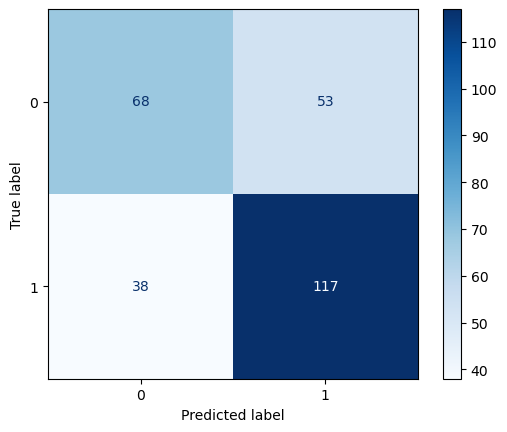

In [87]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_svm,
    cmap = plt.cm.Blues
)
plt.show()

In [88]:
print(classification_report(y_teste, previsoes_svm))

              precision    recall  f1-score   support

           0       0.64      0.56      0.60       121
           1       0.69      0.75      0.72       155

    accuracy                           0.67       276
   macro avg       0.66      0.66      0.66       276
weighted avg       0.67      0.67      0.67       276



## Treino

In [89]:
previsoes_treino = svm.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1,

In [90]:
accuracy_score(y_treino, previsoes_treino)

0.7145085803432137

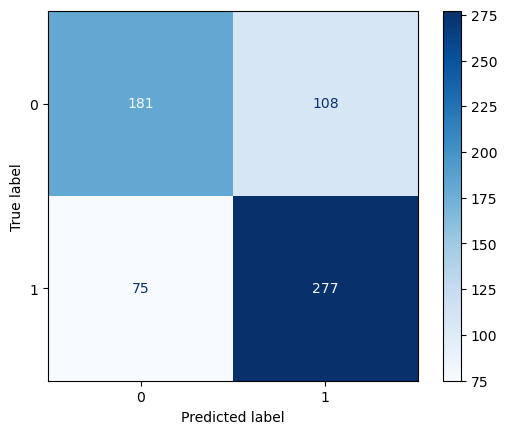

In [91]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [92]:
kfold = KFold(n_splits = 30, shuffle=True,random_state=5)

In [93]:
modelo = SVC(kernel='rbf', random_state=1, C=2)
resultado = cross_val_score(modelo, previsores3_esc, alvo, cv = kfold)

In [94]:
print("Acurácia: %.2f%%" % (resultado.mean() * 100))

Acurácia: 85.72%


# Regreção logistica

## 📌 Introdução
A **Regressão Logística** é um algoritmo de **aprendizado supervisionado** utilizado principalmente para **classificação binária**, mas que pode ser estendido para **classificação multiclasse**.  
Apesar do nome, trata-se de um **modelo de classificação**, não de regressão contínua.

---

## 🎯 Conceito Fundamental

### 🔹 Ideia Central
A Regressão Logística modela a **probabilidade** de uma instância pertencer a uma determinada classe.

- Saída entre **0 e 1**
- Usa uma **função sigmoide** para transformar uma combinação linear das variáveis

---

### 🔹 Função Sigmoide
A função sigmoide comprime qualquer valor real para o intervalo *(0, 1)*:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Onde:

$$
z = w \cdot x + b
$$

---

## 🔧 Funcionamento Matemático

### 📐 Modelo
A probabilidade da classe positiva é dada por:

$$
P(y = 1 \mid x) = \sigma(w \cdot x + b)
$$

Regra de decisão:

$$
\hat{y} =
\begin{cases}
1, & \text{se } P(y=1 \mid x) \geq 0.5 \\
0, & \text{caso contrário}
\end{cases}
$$

---

### 📉 Função de Custo (Log Loss)
A função de perda mede o erro entre as previsões e os valores reais:

$$
J(w, b) = -\frac{1}{n} \sum_{i=1}^{n}
\Big[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\Big]
$$

---

### 🔄 Otimização
O modelo é ajustado minimizando a função de custo por **Gradient Descent**:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Onde:
- $\alpha$ é a **taxa de aprendizado**

---

## 🧮 Interpretação Estatística

### 🔹 Log-Odds
A regressão logística modela o **logaritmo das chances** (log-odds):

$$
\log\left(\frac{p}{1 - p}\right) = w \cdot x + b
$$

Cada coeficiente indica o impacto de uma variável na chance do evento ocorrer.

---

## 📊 Tipos de Regressão Logística

### 1️⃣ Binária
- Duas classes (0 ou 1)

### 2️⃣ Multiclasse
- Mais de duas classes  
- Estratégias:
  - **One-vs-Rest (OvR)**
  - **Softmax (Multinomial)**

---

## ⚙️ Parâmetros Importantes

| Parâmetro | Descrição | Efeito |
|---------|----------|-------|
| **C** | Regularização | Alto → menos regularização<br>Baixo → mais regularização |
| **penalty** | Tipo de regularização | L1 → seleção de variáveis<br>L2 → estabilidade |
| **solver** | Algoritmo de otimização | lbfgs, saga, liblinear |
| **max_iter** | Iterações máximas | Evita não convergência |

---

## ✅ Vantagens
- Simples e rápida  
- Interpretável  
- Retorna probabilidades  
- Boa linha de base para classificação  

---

## ❌ Limitações
- Fronteira de decisão linear  
- Sensível a outliers  
- Não captura relações não lineares sem engenharia de atributos  

---

## 🆚 Regressão Logística vs SVM

| Aspecto | Regressão Logística | SVM |
|------|------------------|-----|
| Saída | Probabilidade | Classe |
| Interpretação | Alta | Baixa |
| Kernel | ❌ | ✅ |
| Escalabilidade | Boa | Média |
| Parâmetros | Menos sensível | Mais sensível |

---

## 🛠️ Aplicações Práticas
- Detecção de spam  
- Diagnóstico médico  
- Análise de crédito  
- Churn de clientes  
- Classificação de risco  


In [95]:
logistica = LogisticRegression(random_state=1, max_iter=600, penalty='l2', tol=0.0001, C=1, solver='lbfgs')
logistica.fit(x_treino, y_treino)

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(C=1, max_iter=600, random_state=1)

In [96]:
logistica.intercept_

array([-3.32203117])

In [97]:
logistica.coef_

array([[ 0.01246027, -1.27824625,  0.66312301,  0.00310833,  0.00427674,
         0.91931116,  0.09210503, -0.01174223,  1.02871067,  0.24768399,
         1.65039657]])

In [98]:
previsoes_logistica = logistica.predict(x_teste)
previsoes_logistica

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [99]:
print('Acurácia: %.2f%%' % (accuracy_score(y_teste, previsoes_logistica) * 100))

Acurácia: 85.51%


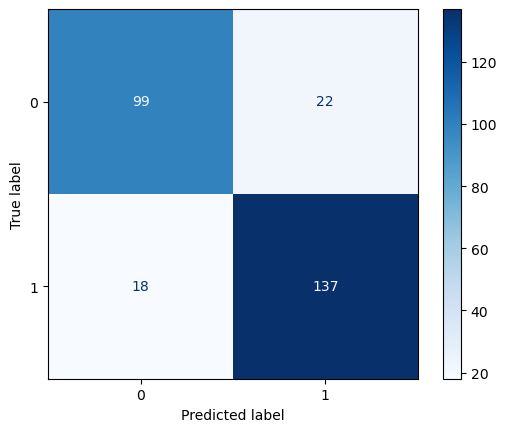

In [100]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_logistica,
    cmap = plt.cm.Blues
)
plt.show()

In [101]:
print(classification_report(y_teste, previsoes_logistica))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       121
           1       0.86      0.88      0.87       155

    accuracy                           0.86       276
   macro avg       0.85      0.85      0.85       276
weighted avg       0.85      0.86      0.85       276



## Analise dados de treino

In [102]:
previsoes_treino = logistica.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,

In [103]:
accuracy_score(y_treino, previsoes_treino)

0.8486739469578783

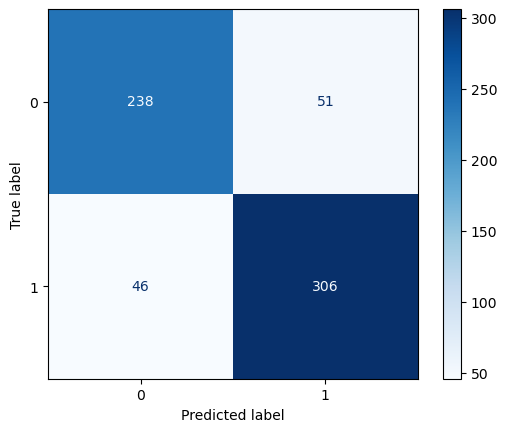

In [104]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [105]:
#separando os dados em folds
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [106]:
modelo = LogisticRegression(random_state=1)
resultado = cross_val_score(modelo, previsores3_esc, alvo, cv = kfold)

In [107]:
print('Acurácia: %.2f%%' % (resultado.mean() * 100))

Acurácia: 85.83%


# Aprendizagem baseada em instâncias (KNN)

## 📌 Introdução
O **KNN (K-Nearest Neighbors)** é um algoritmo de **aprendizado supervisionado** e **não paramétrico**, utilizado tanto para **classificação** quanto para **regressão**.  
Ele é chamado de **aprendizagem baseada em instâncias** porque **não constrói um modelo explícito**: todas as decisões são feitas com base nos dados de treino armazenados.

---

## 🎯 Conceito Fundamental

### 🔹 Ideia Central
Para classificar um novo ponto:
1. Calcula-se a distância entre o ponto novo e **todos os pontos do conjunto de treino**
2. Selecionam-se os **K vizinhos mais próximos**
3. A classe final é definida pela **maioria dos vizinhos**

---

### 🔹 Exemplo Intuitivo
- Se **K = 5**  
- 3 vizinhos são da classe A  
- 2 vizinhos são da classe B  

➡️ O ponto será classificado como **classe A**

---

## 📐 Funcionamento Matemático

### 🔹 Medidas de Distância

**Distância Euclidiana (mais comum)**

$$
d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}
$$

**Distância Manhattan**

$$
d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
$$

**Distância Minkowski (generalização)**

$$
d(x, y) = \left( \sum_{i=1}^{n} |x_i - y_i|^p \right)^{1/p}
$$

- $p = 2$ → Euclidiana  
- $p = 1$ → Manhattan  

---

## 🧮 Classificação e Regressão

### 🔹 KNN para Classificação
A classe prevista é a **moda** das classes dos K vizinhos:

$$
\hat{y} = \text{moda}(y_1, y_2, \dots, y_k)
$$

---

### 🔹 KNN para Regressão
O valor previsto é a **média** dos valores dos K vizinhos:

$$
\hat{y} = \frac{1}{k} \sum_{i=1}^{k} y_i
$$

---

## ⚙️ Parâmetros Importantes

| Parâmetro | Descrição | Efeito |
|---------|----------|-------|
| **n_neighbors (K)** | Número de vizinhos | K pequeno → sensível a ruído<br>K grande → decisão mais suave |
| **metric** | Medida de distância | Afeta diretamente a decisão |
| **weights** | Peso dos vizinhos | `uniform` ou `distance` |
| **p** | Parâmetro da Minkowski | Controla tipo de distância |

---

## 📊 Escolha do Valor de K
- K ímpar evita empates (classificação binária)
- Valores pequenos → **overfitting**
- Valores grandes → **underfitting**
- Usar **validação cruzada** para encontrar o melhor K

---

## 🔄 Normalização dos Dados (Muito Importante!)
KNN é **extremamente sensível à escala** das variáveis.

✔️ Recomenda-se:
- **StandardScaler**
- **MinMaxScaler**

---

## ✅ Vantagens
- Simples de entender e implementar  
- Não requer fase de treinamento explícita  
- Funciona bem para fronteiras complexas  

---

## ❌ Limitações
- Computacionalmente caro (predição lenta)  
- Sensível a ruídos  
- Sensível à escala dos dados  
- Requer muita memória  

---

## 🆚 Comparação com Outros Algoritmos

| Algoritmo | Modelo Explícito | Sensível à Escala | Interpretável |
|---------|----------------|------------------|--------------|
| KNN | ❌ | ✅ | Média |
| Regressão Logística | ✅ | ⚠️ | Alta |
| SVM | ✅ | ⚠️ | Baixa |

---

## 🛠️ Aplicações Práticas
- Sistemas de recomendação  
- Reconhecimento de padrões  
- Diagnóstico médico  
- Classificação de imagens simples  
- Detecção de fraudes  

---

## 📌 Observação Final
KNN é um excelente algoritmo **didático** e funciona bem como **baseline**, mas para grandes volumes de dados, modelos como **SVM, Árvores ou Redes Neurais** costumam ser mais eficientes.

In [108]:
knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=1)
knn.fit(x_treino, y_treino)

KNeighborsClassifier(n_neighbors=7, p=1)

In [109]:
previsoes_knn = knn.predict(x_teste)
previsoes_knn

array([1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [110]:
y_teste

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [111]:
print('Acurácia: %.2f%%' % (accuracy_score(y_teste, previsoes_knn) * 100))

Acurácia: 69.93%


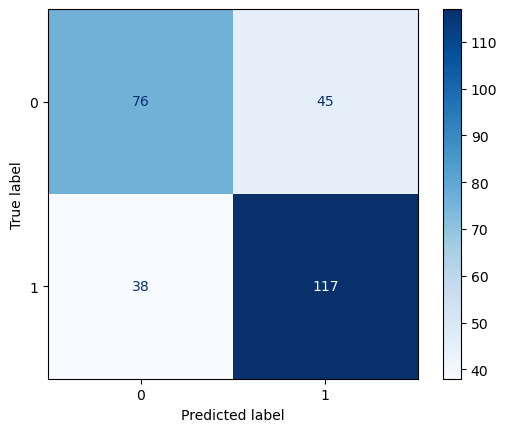

In [112]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_knn,
    cmap = plt.cm.Blues
)
plt.show()

In [113]:
print(classification_report(y_teste, previsoes_knn))

              precision    recall  f1-score   support

           0       0.67      0.63      0.65       121
           1       0.72      0.75      0.74       155

    accuracy                           0.70       276
   macro avg       0.69      0.69      0.69       276
weighted avg       0.70      0.70      0.70       276



## Análise dos dados de treino

In [114]:
previsoes_treino = knn.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,

In [115]:
accuracy_score(y_treino, previsoes_treino)

0.7987519500780031

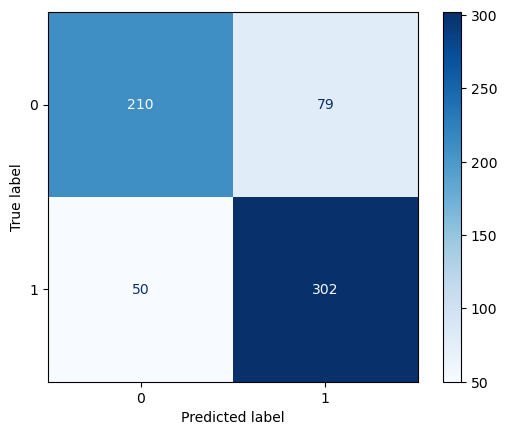

In [116]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [117]:
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [118]:
modelo = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=1)
resultado = cross_val_score(modelo, previsores3_esc, alvo, cv = kfold)

In [119]:
print('Acurácia: %.2f%%' % (resultado.mean() * 100))

Acurácia: 85.84%


# Arvore de decisão 

In [120]:
arvore = DecisionTreeClassifier(criterion='entropy', random_state=0, max_depth = 3)
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [121]:
previsoes_arvore = arvore.predict(x_teste)
previsoes_arvore

array([1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [122]:
y_teste

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [123]:
print('Acuracia: %.2f%%' % (accuracy_score(y_teste, previsoes_arvore) * 100.0))

Acuracia: 83.70%


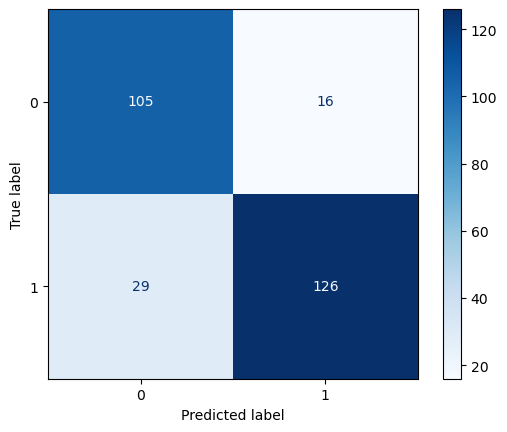

In [124]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_arvore,
    cmap = plt.cm.Blues
)
plt.show()

In [125]:
print(classification_report(y_teste, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       121
           1       0.89      0.81      0.85       155

    accuracy                           0.84       276
   macro avg       0.84      0.84      0.84       276
weighted avg       0.84      0.84      0.84       276



## Análise dados de treino 

In [126]:
previsoes_treino = arvore.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,

In [127]:
accuracy_score(y_treino, previsoes_treino)

0.8517940717628705

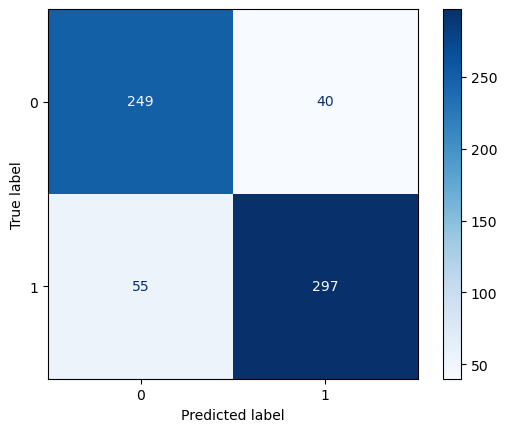

In [128]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [129]:
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [130]:
modelo = DecisionTreeClassifier(criterion='entropy', random_state=0, max_depth=3)
resultado = cross_val_score(modelo, previsores3_esc, alvo, cv = kfold)

In [131]:
print('Acuracia: %.2f%%' % (resultado.mean() * 100.0))

Acuracia: 83.32%


# Random forest

In [132]:
random = RandomForestClassifier(n_estimators = 150, criterion = 'entropy', random_state = 0, max_depth = 4)
random.fit(x_treino, y_treino)

RandomForestClassifier(criterion='entropy', max_depth=4, n_estimators=150,
                       random_state=0)

In [133]:
previsoes_random = random.predict(x_teste)
previsoes_random

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [134]:
y_teste

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [135]:
print('Acuracia: %.2f%%' % (accuracy_score(y_teste, previsoes_random) * 100.0))

Acuracia: 86.59%


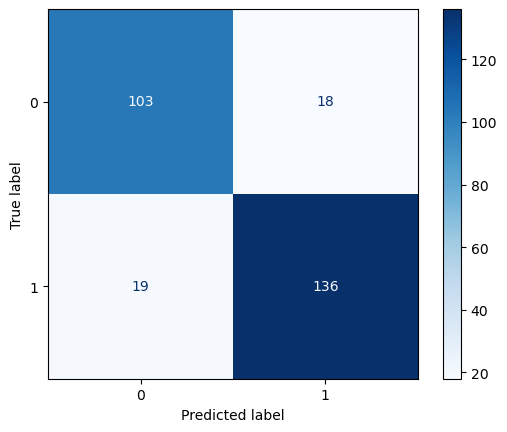

In [136]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_random,
    cmap = plt.cm.Blues
)
plt.show()

In [137]:
print(classification_report(y_teste, previsoes_random))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       121
           1       0.88      0.88      0.88       155

    accuracy                           0.87       276
   macro avg       0.86      0.86      0.86       276
weighted avg       0.87      0.87      0.87       276



## Análise dados de treino 

In [138]:
previsoes_treino = random.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,

In [139]:
accuracy_score(y_treino, previsoes_treino)

0.890795631825273

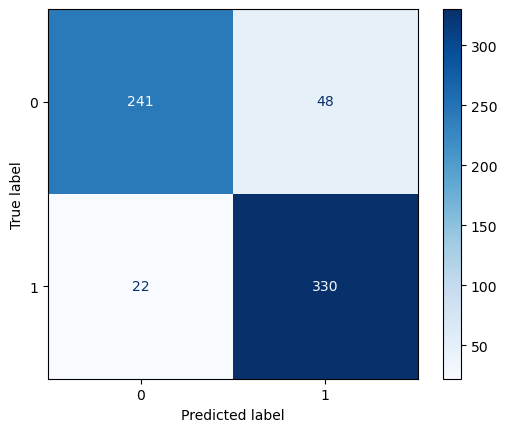

In [140]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [141]:
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [142]:
modelo = RandomForestClassifier(n_estimators=150, criterion='entropy', random_state=0, max_depth=4)
resultado = cross_val_score(modelo, previsores, alvo, cv=kfold)

print('Acuracia media %.2f%%' % (resultado.mean() * 100))

Acuracia media 85.92%


# XGBOOST (eXtreme Gradient Boosting)

In [143]:
xg = XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250, objective='binary:logistic', random_state=3)
xg.fit(x_treino,y_treino)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=250,
              n_jobs=None, num_parallel_tree=None, ...)

In [144]:
previsoes_xg = xg.predict(x_teste)
previsoes_xg

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [145]:
print('Acuracia: %.2f%%' % (accuracy_score(y_teste, previsoes_xg) * 100.0))

Acuracia: 87.32%


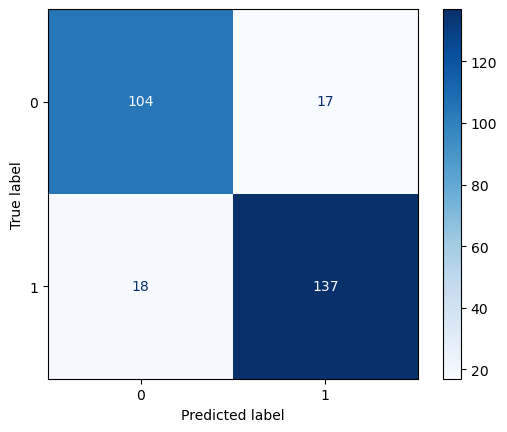

In [146]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_xg,
    cmap = plt.cm.Blues
)
plt.show()

In [147]:
print(classification_report(y_teste, previsoes_xg))

              precision    recall  f1-score   support

           0       0.85      0.86      0.86       121
           1       0.89      0.88      0.89       155

    accuracy                           0.87       276
   macro avg       0.87      0.87      0.87       276
weighted avg       0.87      0.87      0.87       276



## Analise dados de treino

In [148]:
previsoes_treino = xg.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,

In [149]:
accuracy_score(y_treino, previsoes_treino)

0.9173166926677067

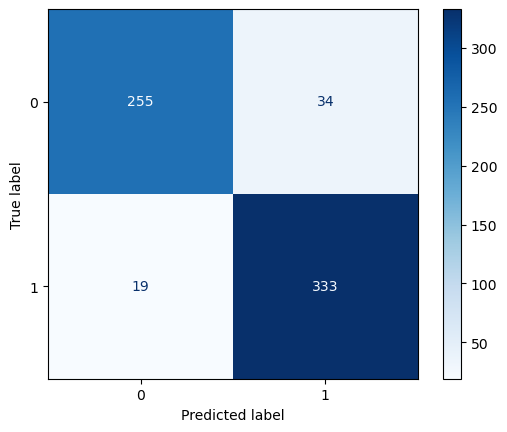

In [150]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

In [151]:
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [152]:
modelo = XGBClassifier(max_depth = 2, learning_rate = 0.05, n_estimators=250, objective='binary:logistic', random_state = 3)
resultado = cross_val_score(modelo, previsores, alvo, cv=kfold)

print('Acurácia Média: %.2f%%' % (resultado.mean() * 100))

Acurácia Média: 87.02%


# Light GBM

In [153]:
dataset = lgb.Dataset(x_treino, label=y_treino)

In [154]:
parametros = {
    'num_leaves':250,
    'objective':'binary',
    'max_depth':2,
    'learning_rate':.05,
    'max_bin':100
}

In [155]:
lgbm = lgb.train(parametros, dataset, num_boost_round = 200)

[LightGBM] [Info] Number of positive: 352, number of negative: 289
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 641, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.549142 -> initscore=0.197204
[LightGBM] [Info] Start training from score 0.197204
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [156]:
inicio = datetime.now()
lgbm = lgb.train(parametros, dataset)
fim = datetime.now()

[LightGBM] [Info] Number of positive: 352, number of negative: 289
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 641, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.549142 -> initscore=0.197204
[LightGBM] [Info] Start training from score 0.197204
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

In [157]:
tempo = fim-inicio
tempo

datetime.timedelta(microseconds=13367)

In [158]:
previsoes_lgbm = lgbm.predict(x_teste)
previsoes_lgbm

array([0.8631083 , 0.83285722, 0.94121847, 0.06260666, 0.15908234,
       0.33596225, 0.44795132, 0.04080421, 0.06681764, 0.10646924,
       0.87293215, 0.85666014, 0.94121847, 0.92509557, 0.38578614,
       0.89352895, 0.68203754, 0.90039234, 0.89886887, 0.20832387,
       0.91127604, 0.91253524, 0.64552617, 0.23798301, 0.06075688,
       0.04290165, 0.89685493, 0.94636401, 0.62332556, 0.62401938,
       0.9070605 , 0.07879909, 0.0722919 , 0.08016473, 0.74953452,
       0.13491234, 0.20813334, 0.0668571 , 0.65237727, 0.0341922 ,
       0.0442399 , 0.9138597 , 0.89253651, 0.94845106, 0.91035189,
       0.09338637, 0.02879235, 0.87679209, 0.41602918, 0.94588648,
       0.88002128, 0.1340031 , 0.14784491, 0.36115723, 0.94362517,
       0.19719527, 0.10324206, 0.15242684, 0.54934888, 0.1420239 ,
       0.92777162, 0.85094376, 0.62064475, 0.13917976, 0.9369576 ,
       0.62849277, 0.94786119, 0.33767584, 0.9156089 , 0.13917976,
       0.84932712, 0.86621385, 0.3177706 , 0.94362517, 0.88056

In [159]:
previsoes_lgbm.shape

(276,)

In [160]:
for i in range(0, 276):
    if previsoes_lgbm[i] >= .5:
        previsoes_lgbm[i] = 1
    else:
        previsoes_lgbm[i] = 0

In [161]:
previsoes_lgbm

array([1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0.,
       1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
       0., 0., 0., 1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1.,
       1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1.,
       1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1.,
       1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1., 1.,
       0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 0.,
       1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0.,
       1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1.,
       1., 0., 0., 0., 1., 0., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1.,
       0., 0., 1., 1., 1.

In [162]:
y_teste

array([1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [163]:
print('Acuracia: %.2f%%' % (accuracy_score(y_teste, previsoes_lgbm) * 100 ))

Acuracia: 86.59%


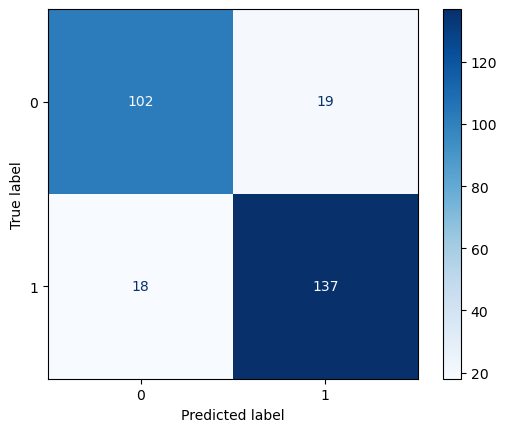

In [164]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_lgbm,
    cmap = plt.cm.Blues
)
plt.show()

## Analise com dados de treino

In [165]:
previsoes_treino = lgbm.predict(x_treino)
previsoes_treino

array([0.88387506, 0.52323924, 0.90744562, 0.83876831, 0.71445756,
       0.62509401, 0.15160555, 0.03207216, 0.07361481, 0.08780439,
       0.89361033, 0.06785013, 0.85243896, 0.8198371 , 0.90340223,
       0.02067333, 0.04854085, 0.21634752, 0.31009387, 0.92509557,
       0.42055273, 0.72466162, 0.89361033, 0.85396398, 0.78532788,
       0.12536091, 0.20835896, 0.84283679, 0.59988603, 0.89150775,
       0.94249694, 0.02067333, 0.89517269, 0.94710793, 0.06858269,
       0.25380743, 0.8055276 , 0.63277579, 0.05043591, 0.84831906,
       0.15248551, 0.91471384, 0.10732662, 0.09033864, 0.9245565 ,
       0.94455068, 0.12322972, 0.92236955, 0.93654586, 0.84459819,
       0.54067727, 0.09412674, 0.79713073, 0.41513822, 0.92073466,
       0.32725595, 0.87600516, 0.05747886, 0.79991362, 0.09338637,
       0.0539453 , 0.0740234 , 0.51741263, 0.03207216, 0.91913409,
       0.86002219, 0.09114629, 0.6124623 , 0.96604667, 0.02305023,
       0.56559723, 0.89581636, 0.95696552, 0.95642146, 0.05948

In [166]:
previsoes_treino.shape

(641,)

In [167]:
for i in range(0, 641):
    if previsoes_treino[i] >= .5:
        previsoes_treino[i] = 1
    else:
        previsoes_treino[i] = 0

In [168]:
previsoes_treino 

array([1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0.,
       0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1.,
       0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1., 1., 1.,
       0., 1., 0., 1., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1., 1., 0., 1.,
       1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 0., 1.,
       0., 0., 0., 0., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 0., 0.,
       1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 1.,
       0., 1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0.,
       0., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 0., 0., 1.,
       1., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1.,
       0., 0., 1., 1., 1.

In [169]:
accuracy_score(y_treino, previsoes_treino)

0.8954758190327613

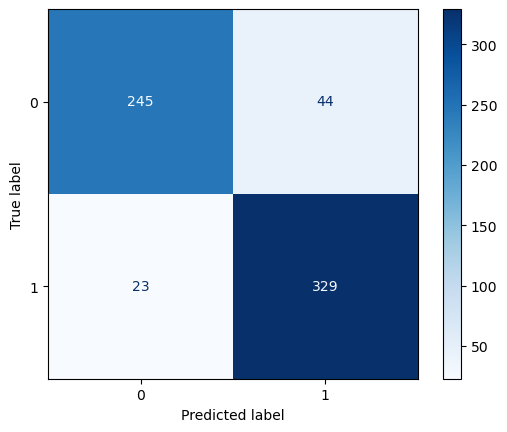

In [170]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [171]:
kfold = KFold(n_splits=30, shuffle=True, random_state=5)

In [172]:
modelo = lgb.LGBMClassifier(num_leaves=250, objective='binary', max_depth=2, learning_rate=.05, max_bin = 150)
resultado = cross_val_score(modelo, previsores3, alvo, cv = kfold)

[LightGBM] [Info] Number of positive: 489, number of negative: 397
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 886, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.551919 -> initscore=0.208426
[LightGBM] [Info] Start training from score 0.208426
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/s

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMClassifier was fitted with feature names

/home/rodriggo/anaconda3/lib/python3.13/site-packages/s

In [173]:
print('Acuracia média %.2f%%' % (resultado.mean()*100))

Acuracia média 86.58%


# Grid Search (Classificador gradient boosting)

In [174]:
gbm = GradientBoostingClassifier(random_state = 0)

In [175]:
# Determinando tamanho do hiperparametro
param_grid = dict(
    n_estimators = [20,50,100,250],
    learning_rate = [0.05,0.1,0.5],
    max_depth=[1,2,3,4,5]
)

In [176]:
print('Numero de combinações de hiperparametros: ', 
     len(param_grid['n_estimators']) * len(param_grid['learning_rate']) * len(param_grid['max_depth']))

Numero de combinações de hiperparametros:  60


In [177]:
grid_search = GridSearchCV(gbm, param_grid, scoring='roc_auc', cv = 4)

In [178]:
grid_search.fit(x_treino, y_treino)

GridSearchCV(cv=4, estimator=GradientBoostingClassifier(random_state=0),
             param_grid={'learning_rate': [0.05, 0.1, 0.5],
                         'max_depth': [1, 2, 3, 4, 5],
                         'n_estimators': [20, 50, 100, 250]},
             scoring='roc_auc')

In [201]:
grid_search.best_params_

{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 50}

In [203]:
resultado = pd.DataFrame(grid_search.cv_results_)
print(resultado.shape)
resultado.head(3)

(60, 15)


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,mean_test_score,std_test_score,rank_test_score
0,0.014950,0.002657,0.001490,0.000137,0.05,1,20,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est...",0.902553,0.868608,0.948548,0.878472,0.899545,0.030869,53
1,0.026656,0.000510,0.001166,0.000036,0.05,1,50,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est...",0.909869,0.881550,0.960385,0.890309,0.910528,0.030556,22
2,0.049489,0.000269,0.001233,0.000042,0.05,1,100,"{'learning_rate': 0.05, 'max_depth': 1, 'n_est...",0.920065,0.894176,0.966304,0.892992,0.918384,0.029706,6


In [204]:
resultado.sort_values(by='mean_test_score', ascending = True, inplace = True)

resultado.reset_index(drop=True, inplace=True)

resultado[['param_max_depth', 'param_learning_rate', 'param_n_estimators', 'mean_test_score', 'std_test_score']].head()

,param_max_depth,param_learning_rate,param_n_estimators,mean_test_score,std_test_score
0,2,0.5,250,0.888222,0.015454
1,2,0.5,100,0.891588,0.022827
2,3,0.5,250,0.892135,0.010465
3,3,0.5,100,0.893703,0.008720
4,3,0.5,50,0.893969,0.008354


# CatBoost

In [179]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
912,45,M,TA,110,264.0,0,Normal,132,N,1.2,Flat,1
913,68,M,ASY,144,193.0,1,Normal,141,N,3.4,Flat,1
914,57,M,ASY,130,131.0,0,Normal,115,Y,1.2,Flat,1
915,57,F,ATA,130,236.0,0,LVH,174,N,0.0,Flat,1


In [180]:
previsores4 = df.iloc[:, 0:11]

In [181]:
previsores4.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140,289.0,0,Normal,172,N,0.0,Up
1,49,F,NAP,160,180.0,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130,283.0,0,ST,98,N,0.0,Up
3,48,F,ASY,138,214.0,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150,195.0,0,Normal,122,N,0.0,Up


In [182]:
alvo4 = df.iloc[:, 11]

In [183]:
x_treino, x_teste, y_treino, y_teste = train_test_split(previsores4, alvo4, test_size = 0.3, random_state = 0)

In [184]:
categoricas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

In [185]:
catboost = CatBoostClassifier(task_type='CPU', iterations=100, learning_rate=0.1, depth=8, random_state=5, eval_metric='Accuracy')

In [186]:
catboost.fit(x_treino, y_treino, cat_features=categoricas, plot=True, eval_set=(x_teste, y_teste))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.8861154	test: 0.7789855	best: 0.7789855 (0)	total: 49.2ms	remaining: 4.87s
1:	learn: 0.8689548	test: 0.7934783	best: 0.7934783 (1)	total: 50.9ms	remaining: 2.49s
2:	learn: 0.8471139	test: 0.7971014	best: 0.7971014 (2)	total: 51.6ms	remaining: 1.67s
3:	learn: 0.8549142	test: 0.8043478	best: 0.8043478 (3)	total: 52.9ms	remaining: 1.27s
4:	learn: 0.8517941	test: 0.8043478	best: 0.8043478 (3)	total: 54.3ms	remaining: 1.03s
5:	learn: 0.8486739	test: 0.8043478	best: 0.8043478 (3)	total: 55.7ms	remaining: 873ms
6:	learn: 0.8580343	test: 0.8115942	best: 0.8115942 (6)	total: 57ms	remaining: 757ms
7:	learn: 0.8642746	test: 0.8043478	best: 0.8115942 (6)	total: 58.4ms	remaining: 671ms
8:	learn: 0.8533541	test: 0.8043478	best: 0.8115942 (6)	total: 61ms	remaining: 617ms
9:	learn: 0.8611544	test: 0.8115942	best: 0.8115942 (6)	total: 62.6ms	remaining: 563ms
10:	learn: 0.8642746	test: 0.8079710	best: 0.8115942 (6)	total: 63.9ms	remaining: 517ms
11:	learn: 0.8658346	test: 0.8043478	best: 0.8

In [187]:
previsoes_cat = catboost.predict(x_teste)
previsoes_cat

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1])

In [188]:
y_teste

306    1
710    0
298    1
466    0
253    0
      ..
49     1
456    1
342    1
906    1
116    1
Name: HeartDisease, Length: 276, dtype: int64

In [189]:
print('Acuracia: %.2f%%' % (accuracy_score(y_teste, previsoes_cat) * 100 ))

Acuracia: 86.96%


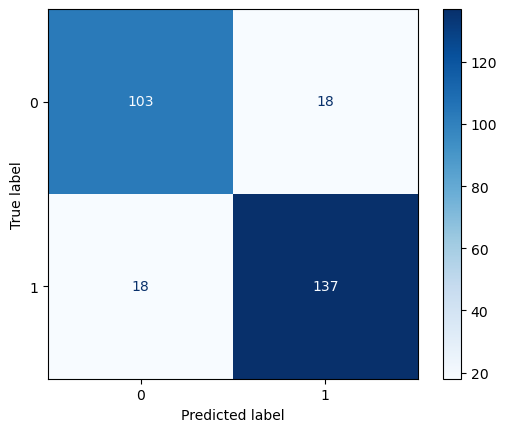

In [190]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_teste, 
    previsoes_cat,
    cmap = plt.cm.Blues
)
plt.show()

## Análise dados de treino 

In [191]:
previsoes_treino = catboost.predict(x_treino)
previsoes_treino

array([1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1,

In [192]:
accuracy_score(y_treino, previsoes_treino)

0.9173166926677067

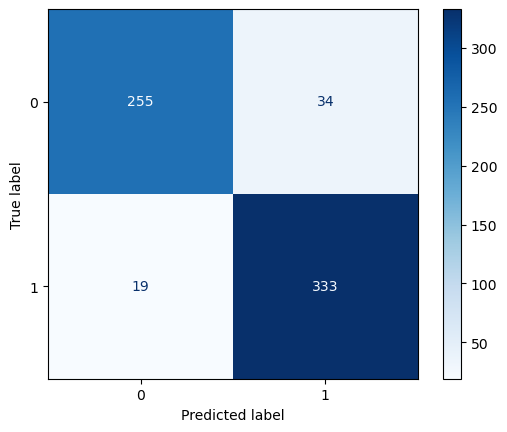

In [193]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_treino, 
    previsoes_treino,
    cmap = plt.cm.Blues
)
plt.show()

## Validação cruzada

In [194]:
kfold = KFold(n_splits = 30, shuffle=True, random_state=5)

In [195]:
modelo = CatBoostClassifier(task_type='CPU', iterations=100, learning_rate=0.1, depth=8, random_state=5, eval_metric='Accuracy')
resultado = cross_val_score(modelo, previsores, alvo, cv = kfold)

0:	learn: 0.8803612	total: 1.25ms	remaining: 124ms
1:	learn: 0.8758465	total: 2.75ms	remaining: 135ms
2:	learn: 0.8837472	total: 3.78ms	remaining: 122ms
3:	learn: 0.8927765	total: 4.84ms	remaining: 116ms
4:	learn: 0.8792325	total: 5.19ms	remaining: 98.7ms
5:	learn: 0.8803612	total: 6.69ms	remaining: 105ms
6:	learn: 0.8893905	total: 7.75ms	remaining: 103ms
7:	learn: 0.8860045	total: 8.74ms	remaining: 101ms
8:	learn: 0.8927765	total: 9.81ms	remaining: 99.2ms
9:	learn: 0.8950339	total: 11ms	remaining: 99.1ms
10:	learn: 0.8950339	total: 12.2ms	remaining: 98.8ms
11:	learn: 0.8961625	total: 13.2ms	remaining: 96.8ms
12:	learn: 0.8972912	total: 14.2ms	remaining: 95.3ms
13:	learn: 0.8972912	total: 15.1ms	remaining: 92.9ms
14:	learn: 0.8995485	total: 16.4ms	remaining: 92.7ms
15:	learn: 0.9006772	total: 17.5ms	remaining: 91.7ms
16:	learn: 0.9029345	total: 18.5ms	remaining: 90.4ms
17:	learn: 0.9040632	total: 19.4ms	remaining: 88.6ms
18:	learn: 0.9018059	total: 19.7ms	remaining: 83.9ms
19:	learn: 0

In [196]:
print('Acuracia média: %.2f%%' % (resultado.mean() * 100))

Acuracia média: 88.00%


# Resultados dos Modelos de Classificação

- **Naive Bayes**  
  - Acurácia (treino e teste): **84,78%**  
  - Acertos: **234**  
  - Validação cruzada: **85,17%**  
  - Previsores: `previsores3_esc`

- **SVM (Support Vector Machine)**  
  - Acurácia: **86,23%**  
  - Acertos: **238**  
  - Validação cruzada: **85,72%**  
  - Previsores: `previsores3_esc`  
  - Modelo: `SVC(kernel='rbf', random_state=1, C=2)`

- **Regressão Logística**  
  - Acurácia: **86,23%**  
  - Acertos: **238**  
  - Validação cruzada: **85,83%**  
  - Previsores: `previsores3_esc`  
  - Modelo: `LogisticRegression(random_state=1, max_iter=600, penalty='l2', tol=0.0001, C=1, solver='lbfgs')`

- **KNN (K-Nearest Neighbors)**  
  - Acurácia: **84,06%**  
  - Acertos: **232**  
  - Validação cruzada: **85,84%**  
  - Previsores: `previsores_esc`  
  - Modelo: `KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=1)`

- **Árvore de Decisão**  
  - Acurácia (treino e teste): **83,7%**  
  - Acertos: **231**  
  - Validação cruzada: **83,32%**  
  - Previsores: `previsores3_esc`  
  - Modelo: `DecisionTreeClassifier(criterion='entropy', random_state=0, max_depth=3)`

- **Random Forest**  
  - Acurácia: **86,59%**  
  - Acertos: **239**  
  - Validação cruzada: **85,92%**  
  - Previsores: `previsores`  
  - Modelo: `RandomForestClassifier(n_estimators=150, criterion='entropy', random_state=0, max_depth=4)`

- **XGBoost**  
  - Acurácia: **87,68%**  
  - Acertos: **242**  
  - Validação cruzada: **87,13%**  
  - Previsores: `previsores`  
  - Modelo: `XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=250, objective='binary:logistic', random_state=3)`

- **LightGBM**  
  - Acurácia (treino e teste): **86,23%**  
  - Acertos: **238**  
  - Validação cruzada: **85,93%**  
  - Previsores: `previsores`  
  - Modelo: `lgb.LGBMClassifier(num_leaves=250, objective='binary', max_depth=2, learning_rate=0.05, max_bin=100)`

- **CatBoost**  
  - Acurácia (treino e teste): **86,96%**  
  - Acertos: **240**  
  - Validação cruzada: **88%**  
  - Previsores: `previsores (Validação cruzada apenas)`  
  - Modelo: `CatBoostClassifier(task_type='CPU', iterations=100, learning_rate=0.1, depth=8, random_state=5, eval_metric='Accuracy')`


# Salvando dados para deploy

In [197]:
previsores

array([[40. ,  0. ,  1. , ...,  0. ,  0. ,  0. ],
       [49. ,  1. ,  2. , ...,  0. ,  1. ,  1. ],
       [37. ,  0. ,  1. , ...,  0. ,  0. ,  0. ],
       ...,
       [57. ,  0. ,  3. , ...,  1. ,  1.2,  1. ],
       [57. ,  1. ,  1. , ...,  0. ,  0. ,  1. ],
       [38. ,  0. ,  2. , ...,  0. ,  0. ,  0. ]])

In [198]:
alvo

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,

In [199]:
np.savetxt('previsores.csv', previsores, delimiter=',')

In [200]:
np.savetxt('alvo.csv', alvo, delimiter = ',')